# Modeling

Consolidates the modeling pipeline on top of `04-AGE-feture_selection.ipynb`'s
consensus-selected features (`data/processed/selected_features.json`):
train/validation/test split on PTB-XL's official `strat_fold` (folds 1-8
train, 9 validation, 10 test -- no patient leakage), a `LogisticRegression`
baseline, `RandomizedSearchCV`-tuned `XGBClassifier`, and MLflow tracking for
both via `ExperimentTracking`.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import randint, uniform
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import PredefinedSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

from ptbxl.models.tracking import ExperimentTracking
from ptbxl.utils.paths import data_interim_dir, data_processed_dir

sns.set_theme()
RANDOM_STATE = 42

/home/age90/Projects/ptbxl-challenge/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

Same `dataset_metadata` and per-domain feature CSVs notebook 04 used, plus the
consensus feature list it persisted.

In [3]:
target_column = 'target'
demographic_columns = ['age', 'sex']

dataset_metadata = pd.read_csv(data_interim_dir('dataset_metadata.csv'))
dataset_metadata = dataset_metadata.set_index('ecg_id')

domain_files = {
    'dominant_frequency': 'dominant_freq_dataset.csv',
    'spectral_entropy': 'spec_entropy_dataset.csv',
    'wavelet_decomposition': 'wave_dec_dataset.csv',
    'time_domain': 'time_domain_dataset.csv',
    'heart_rate': 'heart_rate_dataset.csv',
    'wave_spectral': 'wave_spectral_dataset.csv',
}
domain_frames = {
    domain_key: pd.read_csv(data_processed_dir(filename)).set_index('ecg_id')
    for domain_key, filename in domain_files.items()
}

with open(data_processed_dir('selected_features.json')) as f:
    consensus_features_by_domain = json.load(f)

X_final = pd.concat(
    [dataset_metadata[demographic_columns]]
    + [
        domain_frames[domain_key][features]
        for domain_key, features in consensus_features_by_domain.items()
    ],
    axis=1,
).astype(float)
y_final = dataset_metadata[target_column].astype(int)

print(f'Feature matrix: {X_final.shape[1]} columns, {X_final.shape[0]} records')
display(X_final.head())

Feature matrix: 246 columns, 9620 records


,age,sex,DF_V4,DF_V5,l1nrg_aVL,l1nrg_V2,l1nrg_V4,l1mean_V1,l1mean_V2,l1mean_V3,...,T_DF_aVL,T_DF_V1,T_DF_V2,T_DF_V5,T_DF_V6,T_SpecEn_I,T_SpecEn_V1,T_SpecEn_V5,T_SpecEn_V6,n_beats
ecg_id,,,,,,,,,,,,,,,,,,,,,
2,19.0,0.0,0.875,0.875,26.414974,153.427952,136.714596,0.054617,0.173277,-0.041111,...,1.190476,7.142857,5.952381,7.142857,7.142857,3.353158,4.231395,4.056944,3.915267,7.0
12,43.0,1.0,0.750,0.750,1.257927,12.583235,6.990640,0.014713,0.007522,-0.021013,...,6.944444,6.944444,6.944444,6.944444,6.944444,1.342213,1.307468,0.884179,0.877551,6.0
20,56.0,0.0,4.625,4.625,6.016820,31.791701,5.150164,0.034281,0.065933,0.062530,...,13.684211,13.684211,13.684211,16.842105,16.842105,4.811556,4.076251,4.710560,4.738908,18.0
23,56.0,0.0,4.250,4.250,2.373361,37.733143,4.955248,0.015289,0.014456,-0.003839,...,11.320755,11.320755,3.773585,3.773585,6.603774,4.922957,4.536000,4.907213,4.824687,17.0
37,25.0,1.0,3.750,3.750,0.742983,10.849826,3.795875,-0.004684,0.020613,0.008712,...,7.692308,7.692308,7.692308,7.692308,7.692308,1.310953,1.506772,1.085518,1.073123,7.0


## Train / validation / test split (`strat_fold`)

PTB-XL's official, patient-disjoint split (see notebook 01): folds 1-8 for
training, fold 9 for validation, fold 10 for held-out test. Using it directly
avoids the row-level `stratify=target` random split notebook 04 used, which
ignored `strat_fold` and risked leaking a patient's other ECGs across the
train/test boundary.

In [4]:
strat_fold = dataset_metadata['strat_fold']
train_mask = strat_fold.between(1, 8)
val_mask = strat_fold == 9
test_mask = strat_fold == 10

X_train, y_train = X_final[train_mask], y_final[train_mask]
X_val, y_val = X_final[val_mask], y_final[val_mask]
X_test, y_test = X_final[test_mask], y_final[test_mask]

train_patients = set(dataset_metadata.loc[train_mask, 'patient_id'])
val_patients = set(dataset_metadata.loc[val_mask, 'patient_id'])
test_patients = set(dataset_metadata.loc[test_mask, 'patient_id'])
assert not train_patients & val_patients
assert not train_patients & test_patients
assert not val_patients & test_patients

print(f'Train: {len(X_train)} records, {y_train.mean():.3f} positive rate')
print(f'Val:   {len(X_val)} records, {y_val.mean():.3f} positive rate')
print(f'Test:  {len(X_test)} records, {y_test.mean():.3f} positive rate')

# Reuses PTB-XL's own patient-disjoint, target-stratified folds 1-8 as the CV
# splits for hyperparameter search below, instead of inventing a new grouped
# CV scheme.
predefined_split = PredefinedSplit(test_fold=strat_fold[train_mask].to_numpy() - 1)

Train: 7729 records, 0.314 positive rate
Val:   955 records, 0.324 positive rate
Test:  936 records, 0.314 positive rate


## Preprocessing

Median imputation + standardization, fit on train only and applied to
val/test -- same configuration `FeatureSelectionPipeline` used in notebook 04
(`src/ptbxl/features/feature_selection.py`).

In [5]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_proc = pd.DataFrame(
    scaler.fit_transform(imputer.fit_transform(X_train)),
    columns=X_train.columns, index=X_train.index,
)
X_val_proc = pd.DataFrame(
    scaler.transform(imputer.transform(X_val)),
    columns=X_val.columns, index=X_val.index,
)
X_test_proc = pd.DataFrame(
    scaler.transform(imputer.transform(X_test)),
    columns=X_test.columns, index=X_test.index,
)

## Baseline: `LogisticRegression`

Untuned, `class_weight='balanced'` to counteract the ~32% positive rate
(notebook 01), tracked as a reference point before the tuned model.

In [6]:
baseline_model = LogisticRegression(
    max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
)
baseline_model.fit(X_train_proc, y_train)

y_val_pred = baseline_model.predict(X_val_proc)
print(f'Baseline val precision: {precision_score(y_val, y_val_pred):.2f}')
print(f'Baseline val recall:    {recall_score(y_val, y_val_pred):.2f}')
print(f'Baseline val F1:        {f1_score(y_val, y_val_pred):.2f}')
print(f'Baseline val ROC-AUC:   {roc_auc_score(y_val, baseline_model.predict_proba(X_val_proc)[:, 1]):.2f}')

tracker = ExperimentTracking()
tracker.track_experiment(
    experiment_name='Modeling',
    run_name='baseline_logistic_regression',
    model_name='LogisticRegression',
    developer='AGE90',
    model=baseline_model,
    X_train=X_train_proc,
    y_train=y_train,
    X_test=X_val_proc,
    y_test=y_val,
    xgb=False,
    labels=['Negative', 'Positive'],
)

Baseline val precision: 0.74
Baseline val recall:    0.83
Baseline val F1:        0.78
Baseline val ROC-AUC:   0.92


2026/09/02 18:07:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/02 18:07:55 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


## Hyperparameter tuning: `XGBClassifier`

`RandomizedSearchCV` over folds 1-8 (`predefined_split`), scored on ROC-AUC.
`scale_pos_weight` is searched around the train set's negative/positive
ratio rather than fixed, alongside the usual boosting hyperparameters.

In [7]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f'scale_pos_weight (train) = {scale_pos_weight:.2f}')

param_distributions = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(3, 8),
    'learning_rate': uniform(0.01, 0.29),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'scale_pos_weight': uniform(scale_pos_weight * 0.7, scale_pos_weight * 0.6),
}

search = RandomizedSearchCV(
    XGBClassifier(random_state=RANDOM_STATE),
    param_distributions=param_distributions,
    n_iter=20,
    cv=predefined_split,
    scoring='roc_auc',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_train_proc, y_train)

print(f'Best CV ROC-AUC (folds 1-8): {search.best_score_:.3f}')
print('Best params:', search.best_params_)

tuned_model = search.best_estimator_
y_val_pred = tuned_model.predict(X_val_proc)
print(f'Tuned val precision: {precision_score(y_val, y_val_pred):.2f}')
print(f'Tuned val recall:    {recall_score(y_val, y_val_pred):.2f}')
print(f'Tuned val F1:        {f1_score(y_val, y_val_pred):.2f}')
print(f'Tuned val ROC-AUC:   {roc_auc_score(y_val, tuned_model.predict_proba(X_val_proc)[:, 1]):.2f}')

scale_pos_weight (train) = 2.18
Best CV ROC-AUC (folds 1-8): 0.939
Best params: {'colsample_bytree': np.float64(0.662397808134481), 'learning_rate': np.float64(0.026844247528777843), 'max_depth': 7, 'n_estimators': 199, 'scale_pos_weight': np.float64(1.714416006995377), 'subsample': np.float64(0.8603553891795411)}
Tuned val precision: 0.87
Tuned val recall:    0.81
Tuned val F1:        0.84
Tuned val ROC-AUC:   0.94


## Final tracked run (held-out test, fold 10)

The only place `X_test`/fold 10 is touched, run once at the end.

Test precision: 0.92
Test recall:    0.75
Test F1:        0.83
Test ROC-AUC:   0.93


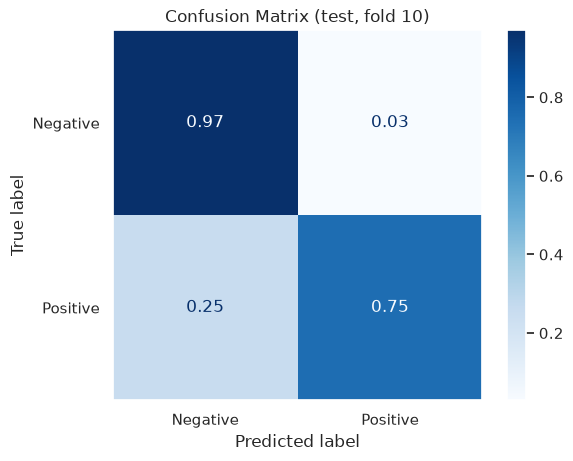

2026/09/02 18:16:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
/home/age90/Projects/ptbxl-challenge/.venv/lib/python3.12/site-packages/xgboost/sklearn.py:1183: UserWarning: [18:16:43] WARNING: /__w/xgboost/xgboost/src/c_api/c_api.cc:1553: Saving model in the UBJSON format as default.  You can use a file extension: `json` or `ubj` to choose between formats.
  self.get_booster().save_model(fname)
2026/09/02 18:16:47 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [8]:
y_test_pred = tuned_model.predict(X_test_proc)
print(f'Test precision: {precision_score(y_test, y_test_pred):.2f}')
print(f'Test recall:    {recall_score(y_test, y_test_pred):.2f}')
print(f'Test F1:        {f1_score(y_test, y_test_pred):.2f}')
print(f'Test ROC-AUC:   {roc_auc_score(y_test, tuned_model.predict_proba(X_test_proc)[:, 1]):.2f}')

cm = confusion_matrix(y_test, y_test_pred, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (test, fold 10)')
plt.grid(False)
plt.show()

tracker.track_experiment(
    experiment_name='Modeling',
    run_name='tuned_xgboost',
    model_name='XGBoost',
    developer='AGE90',
    model=tuned_model,
    X_train=X_train_proc,
    y_train=y_train,
    X_test=X_test_proc,
    y_test=y_test,
    xgb=True,
    labels=['Negative', 'Positive'],
)

## Takeaways

- Splitting by `strat_fold` instead of a random `stratify=target` split
  closes the patient-leakage gap notebook 01 flagged but notebook 04 never
  acted on -- folds 1-8/9/10 are patient-disjoint by construction, verified
  above.
- `RandomizedSearchCV`'s CV folds are PTB-XL's own folds 1-8 via
  `PredefinedSplit`, not an arbitrary K-fold -- this reuses the
  patient-grouped structure already baked into the dataset instead of
  re-deriving it.
- Both runs (baseline `LogisticRegression`, tuned `XGBClassifier`) are logged
  to the `Modeling` MLflow experiment (`tracking/mlflow.db` +
  `tracking/mlruns`) for side-by-side comparison in the MLflow UI.